In [2]:
import torch
from PIL import Image
import core.vision_encoder.pe as pe
import core.vision_encoder.transforms as transforms

print("CLIP configs:", pe.CLIP.available_configs())
# CLIP configs: ['PE-Core-G14-448', 'PE-Core-L14-336', 'PE-Core-B16-224']

model = pe.CLIP.from_config("PE-Core-B16-224", pretrained=True)  # Downloads from HF
model = model.cuda()

CLIP configs: ['PE-Core-G14-448', 'PE-Core-L14-336', 'PE-Core-B16-224']
Missing keys for loading model: []
Unexpected keys for loading model: []


In [3]:
preprocess = transforms.get_image_transform(model.image_size)
tokenizer = transforms.get_text_tokenizer(model.context_length)

In [5]:
import decord
def preprocess_video(video_path, num_frames=8, transform=None, return_first_frame_for_demo=True):
    """
    Uniformly samples a specified number of frames from a video and preprocesses them.
    Parameters:
    - video_path: str, path to the video file.
    - num_frames: int, number of frames to sample. Defaults to 8.
    - transform: torchvision.transforms, a transform function to preprocess frames.
    Returns:
    - Video Tensor: a tensor of shape (num_frames, 3, H, W) where H and W are the height and width of the frames.
    """
    # Load the video
    vr = decord.VideoReader(video_path)
    total_frames = len(vr)
    # Uniformly sample frame indices
    frame_indices = [int(i * (total_frames / num_frames)) for i in range(num_frames)]
    frames = vr.get_batch(frame_indices).asnumpy()
    # Preprocess frames
    preprocessed_frames = [transform(Image.fromarray(frame)) for frame in frames]

    first_frame = None
    if return_first_frame_for_demo:
        first_frame = frames[0]
    return torch.stack(preprocessed_frames, dim=0), first_frame

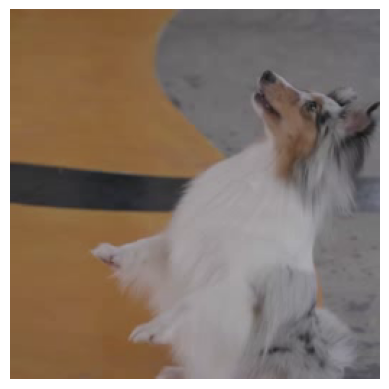

Captions: ['a diagram', 'a dog', 'a cat']
Label probs: 0.00 1.00 0.00
This video is about a dog


In [10]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
captions = ["a diagram", "a dog", "a cat"]

video, first_frame = preprocess_video("/home/firdavs/surgery/surgical_fb_generation/perception_models/apps/pe/docs/assets/dog.mp4", 50, transform=preprocess)
video = video.unsqueeze(0).to(device)
text = tokenizer(["a diagram", "a dog", "a cat"]).to(device)

with torch.no_grad():
    image_features = model.encode_video(video)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1).cpu().numpy()[0]

plt.imshow(Image.fromarray(first_frame))
plt.axis('off')
plt.show()
print("Captions:", captions)
print("Label probs:", ' '.join(['{:.2f}'.format(prob) for prob in text_probs]))  # prints: [[0.00, 1.00, 0.00]]
print(f"This video is about {captions[text_probs.argmax()]}")

In [12]:
video.shape, image_features.shape

(torch.Size([1, 50, 3, 224, 224]), torch.Size([1, 1024]))

In [ ]:
image_features.cpu()

tensor([[-0.0424, -0.0003, -0.0184,  ..., -0.0571,  0.0021,  0.0012]])

: 